## STOCHASTIC MODELING
MODULE 3 | LESSON 2


---


# **MODEL CALIBRATION: MERTON (1976)**


|  |  |
|:---|:---|
|**Reading Time** | 60 minutes |
|**Prior Knowledge** | Fourier Transform, Characteristic Function (CF), Merton (1976), Lewis (2001), Carr-Madan (1999) |
|**Keywords** | Jump diffusion, Model calibration , Merton (1976) |


---

Thr calibration process that we introduced in the last lesson is a general one. Given the characteristic function (CF) of the underlying asset process, we can calibrate every model by using the Lewis (2001) or the Carr-Madan (1999) aproaches. In this lesson, we show this with the Merton (1976) jump-diffusion model.

In [1]:
# Let's start with some libraries that  we will need down the road
import numpy as np
from scipy.integrate import quad
import matplotlib.pyplot as plt

In [2]:
from IPython.display import VimeoVideo

# Bigger video
VimeoVideo("1121445282", h="3298dbabb7", width=700, height=450)

## **1. Merton model: Pricing under Lewis (2001)**

\
Let's start with the calibration of Merton model under the Lewis (2001) approach. As we know, under the Lewis (2001) approach, the value of the Call option is determined by:

\
$$
\begin{equation*}
    C_0 = S_0 - \frac{\sqrt{S_0 K} e^{-rT}}{\pi} \int_{0}^{\infty} \mathbf{Re}[e^{izk} \varphi(z-i/2)] \frac{dz}{z^2+1/4}
\end{equation*}
$$

\
which means that we just need the characteristic function of the process in Merton (1976).

### **1.1. Merton (1976) Characteristic Function**

Merton's (1976) characteristic function is given by:

\
$$
\begin{equation*}
    \varphi^{M76}_0 (u, T) = e^{\left( \left( i u \omega - \frac{u^2 \sigma^2}{2}+ \lambda ( e^{i u \mu_j - u^2 \delta^2/2}-1) \right) T \right)}
\end{equation*}
$$

\
where,

\
$$
\begin{equation*}
    \omega = r - \frac{\sigma^2}{2} - \lambda \left( e^{\mu_j + \delta^2/2}-1 \right)
\end{equation*}
$$

\
Thus, let's start by coding this characteristic function:

In [3]:
def M76_char_func(u, T, r, sigma, lamb, mu, delta):
    """
    Characteristic function for Merton '76 model
    """

    omega = r - 0.5 * sigma**2 - lamb * (np.exp(mu + 0.5 * delta**2) - 1)
    char_func_value = np.exp(
        (
            1j * u * omega
            - 0.5 * u**2 * sigma**2
            + lamb * (np.exp(1j * u * mu - u**2 * delta**2 * 0.5) - 1)
        )
        * T
    )
    return char_func_value

### **1.2. Lewis (2001) Integral Value**

The next step is to define the value of the integral in Lewis (2001) given the characteristic function:

In [4]:
def M76_integration_function(u, S0, K, T, r, sigma, lamb, mu, delta):
    """
    Integral function for Lewis (2001) under Merton'76 characteristic function
    """
    char_func = M76_char_func(u - 0.5 * 1j, T, r, sigma, lamb, mu, delta)

    value = 1 / (u**2 + 0.25) * (np.exp(1j * u * np.log(S0 / K)) * char_func).real

    return value

### 1.3. Call value

Finally, the expression for the value of the Call option today would be:

In [5]:
def M76_call_value(S0, K, T, r, sigma, lamb, mu, delta):
    """
    Value of the Call option under Lewis (2001) for Merton'76 jump diffusion model
    """

    int_value = quad(
        lambda u: M76_integration_function(u, S0, K, T, r, sigma, lamb, mu, delta),
        0,
        50,
        limit=250,
    )[0]

    call_value = max(0, S0 - np.exp(-r * T) * np.sqrt(S0 * K) / np.pi * int_value)

    return call_value

### **1.4. Pricing Example with Given Parameters**

Once we have this set of functions, we can, given some parameters, price a call option under the Merton (1976) jump diffusion model.

For example, assume the following parameters:

- $S_0 = 100$
- $K = 100$
- $T=1$
- $r = 0.05$
- $\sigma = 0.4$
- $\lambda = 1.0$
- $\mu = -0.2$
- $\delta = 0.1$

What would be the price of a Call option under Lewis (2001)?

In [6]:
# Parameters
S0 = 100
K = 100
T = 1
r = 0.05
sigma = 0.4
lamb = 1
mu = -0.2
delta = 0.1

In [7]:
print(
    "Value of the Call option under Merton (1976) is:  $",
    M76_call_value(S0, K, T, r, sigma, lamb, mu, delta),
)

Value of the Call option under Merton (1976) is:  $ 19.947853881446505


## **2. Merton Model Calibration**

The next step is to calibrate the Merton (1976) model to observed option market prices in order to infer the model parameters. In order to do so, we are going to follow a very similar approach to that of the Heston model. In fact, we are going to use the same option market data file from the previous module on EuroStoxx 50 options.


Let's start by importing some additional libraries needed:

In [8]:
import pandas as pd
from scipy.optimize import brute, fmin

### 2.1. Gather Options' Market Data

Next, let's load the data on market prices:

In [9]:
# Market Data from www.eurexchange.com
# as of September 30, 2014

h5 = pd.HDFStore(
    "option_data_wqu.h5", "r"
    )
data = h5["data"]  # European call & put option data (3 maturities)
h5.close()
S0 = 3225.93  # EURO STOXX 50 level September 30, 2014

In [10]:
data.head()

,Date,Strike,Call,Maturity,Put
0,1412035200000000000,1850.0,1373.6,1418947200000000000,0.5
1,1412035200000000000,1900.0,1323.7,1418947200000000000,0.6
2,1412035200000000000,1950.0,1273.8,1418947200000000000,0.8
3,1412035200000000000,2000.0,1223.9,1418947200000000000,0.9
4,1412035200000000000,2050.0,1174.1,1418947200000000000,1.1


As before, we will select near ATM options:

In [11]:
# Option Selection

tol = 0.02  # Tolerance level to select ATM options (percent around ITM/OTM options)
options = data[(np.abs(data["Strike"] - S0) / S0) < tol]
options = options.copy()
options["Date"] = pd.to_datetime(options["Date"])
options["Maturity"] = pd.to_datetime(options["Maturity"])

Then, we add time left until maturity and a constant risk-free rate:

In [12]:
for row, option in options.iterrows():
    T = (option["Maturity"] - option["Date"]).days / 365.0
    options.loc[row, "T"] = T
    options.loc[row, "r"] = 0.005 # Let's use ECB base rate for a change!

In [13]:
options

,Date,Strike,Call,Maturity,Put,T,r
38,2014-09-30,3175.0,126.8,2014-12-19,78.8,0.219178,0.005
39,2014-09-30,3200.0,110.9,2014-12-19,87.9,0.219178,0.005
40,2014-09-30,3225.0,96.1,2014-12-19,98.1,0.219178,0.005
41,2014-09-30,3250.0,82.3,2014-12-19,109.3,0.219178,0.005
42,2014-09-30,3275.0,69.6,2014-12-19,121.6,0.219178,0.005
342,2014-09-30,3175.0,171.0,2015-03-20,129.2,0.468493,0.005
343,2014-09-30,3200.0,156.1,2015-03-20,139.4,0.468493,0.005
344,2014-09-30,3225.0,142.0,2015-03-20,150.3,0.468493,0.005
345,2014-09-30,3250.0,128.5,2015-03-20,161.8,0.468493,0.005
346,2014-09-30,3275.0,115.8,2015-03-20,174.0,0.468493,0.005


### 2.2. Defining Error Functions

Once we have options market data that we have to "match" with our model, our next step is to define an error function for the specific case of the Merton model.

In this case, we will use the **Root Mean Squared Error (RMSE)** as a measure. This is basically defined as:

\
\begin{equation*}
    RMSE = \sqrt{\frac{1}{N}\sum_{n=1}^N \left( C^*_n - C^{M76}_n\right)^2}
\end{equation*}

\
where $C^*$ is observed market prices and $C^{M76}$ are the values produced by Merton's (1976) model.

In [14]:
i = 0
min_RMSE = 100

In [15]:
def M76_error_function(p0):
    """
    Error function for parameter calibration in Merton'76 model
    ---------------
    Parameters to calibrate:
    sigma: float
          volatility factor in diffusion term
    lambda: float
          jump intensity
    mu: float
          expected jump size
    delta: float
          standard deviation of jump
    ----------------
    RMSE: Root Mean Squared Error
    """
    global i, min_RMSE
    sigma, lamb, mu, delta = p0

    if sigma < 0.0 or delta < 0.0 or lamb < 0.0:
        return 500.0
    se = []

    for row, option in options.iterrows():
        model_value = M76_call_value(
            S0, option["Strike"], option["T"], option["r"], sigma, lamb, mu, delta
        )
        se.append((model_value - option["Call"]) ** 2)

    RMSE = np.sqrt(sum(se) / len(se))
    min_RMSE = min(min_RMSE, RMSE)
    if i % 50 == 0:
        print("%4d |" % i, np.array(p0), "| %7.3f | %7.3f" % (RMSE, min_RMSE))
    i += 1
    return RMSE

As before, we are only going to calibrate to Call options. Now that you know how to calibrate models, it would be a very good practice exercise to try modify this code to include both Call and Put option data in the calibration. This is actually going to be part of your assignments, so practicing on it now would be a good investment!




### 2.3. Calibration Function

Next, we need to create our calibration function. This follows the same logic as in the case of Heston . For illustrative purposes, let's set a somewhat high tolerance level so that the optimization does not convey time. By the end of this module, we will dig deeper into the different issues that arise when accurately calibrating a model.

In [16]:
def M76_calibration_full():
    """
    Calibrates Merton (1976) stochastic volatility model to market quotes
    """
    # First run with brute force
    # (scan sensible regions, for faster convergence)
    p0 = brute(
        M76_error_function,
        (
            (0.075, 0.201, 0.025),  # sigma
            (0.10, 0.401, 0.1),  # lambda
            (-0.5, 0.01, 0.1),  # mu
            (0.10, 0.301, 0.1),
        ),  # delta
        finish=None,
    )

    # Second run with local, convex minimization
    # (we dig deeper where promising results)
    opt = fmin(
        M76_error_function, p0, xtol=0.0001, ftol=0.0001, maxiter=550, maxfun=1050
    )
    return opt

### 2.4. Results from Calibration

Finally, let's see how good (or bad) of a fit our calibration achieves!

In [17]:
opt = M76_calibration_full()

   0 | [ 0.075  0.1   -0.5    0.1  ] |  31.540 |  31.540
  50 | [ 0.075  0.3   -0.1    0.3  ] |  22.852 |  11.298
 100 | [ 0.1  0.2 -0.2  0.2] |  19.922 |   8.654
 150 | [ 0.125  0.1   -0.3    0.1  ] |  10.704 |   5.571
 200 | [ 0.125  0.4   -0.5    0.3  ] |  55.500 |   4.662
 250 | [0.15 0.2  0.   0.2 ] |   6.619 |   3.586
 300 | [ 0.175  0.1   -0.1    0.1  ] |  14.171 |   3.586
 350 | [ 0.175  0.4   -0.3    0.3  ] |  54.376 |   3.586
 400 | [ 0.2  0.3 -0.4  0.2] |  63.380 |   3.586
 450 | [ 0.14702168  0.19533978 -0.10189428  0.10218084] |   3.495 |   3.428
 500 | [ 0.14987758  0.11503181 -0.14398098  0.09850597] |   3.401 |   3.401
 550 | [ 0.15597729  0.01124105 -0.20255149  0.07785796] |   3.359 |   3.359
 600 | [ 0.15617567  0.00947711 -0.20364524  0.07721602] |   3.358 |   3.358
Optimization terminated successfully.
         Current function value: 3.358419
         Iterations: 107
         Function evaluations: 183


A central step to assess the fit of the calibration is via visualizations. We would like that the calibrated prices are as close as possible to market ones. Usually, we do this by maturity:

In [18]:
def generate_plot(opt, options):
    # First, we calculate model prices
    sigma, lamb, mu, delta = opt
    options["Model"] = 0.0
    for row, option in options.iterrows():
        options.loc[row, "Model"] = M76_call_value(
            S0, option["Strike"], option["T"], option["r"], sigma, lamb, mu, delta
        )

    # Second, we plot
    mats = sorted(set(options["Maturity"]))
    options = options.set_index("Strike")
    for i, mat in enumerate(mats):
        options[options["Maturity"] == mat][["Call", "Model"]].plot(
            style=["b-", "ro"], title="%s" % str(mat)[:10]
        )
        plt.ylabel("Option Value")

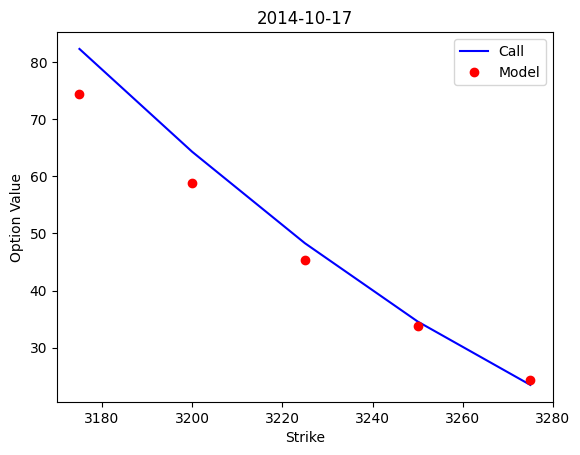

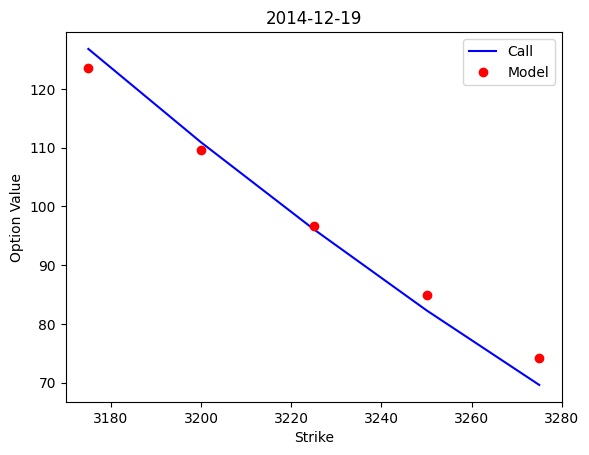

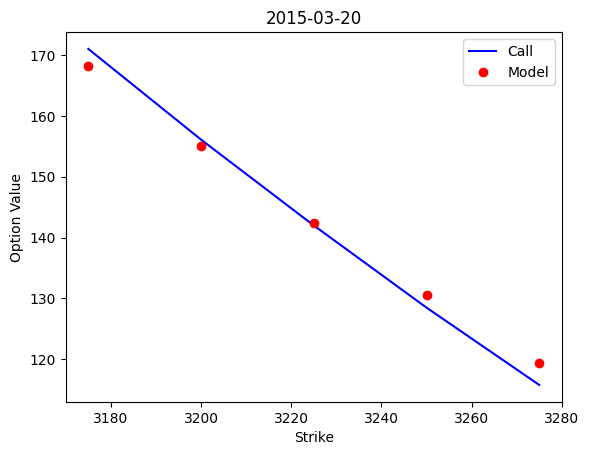

In [19]:
generate_plot(opt, options)

## **3. Conclusion**

This is all regarding Merton (1976) model calibration. We have basically repeated the process of the last module with Heston (1993) and adapted things to the Merton jump diffusion model.

Now that you know how to properly calibrate somewhat simple models, we are going to make a step forward and look at a more complex one. Ideally, a model would incorporate stochastic volatility features present in Heston (1993), with the jump diffusion of Merton (1976). The question is, can we build a model that incorporates both of these desirable characteristics?

The answer is yes, and that's what we will begin to explore in the next lesson.

\
**References**

- Gatheral, Jim. *The Volatility Surface: A Practitioner's Guide*. John Wiley & Sons Inc., 2006.

- Merton, Robert C. "Option pricing when underlying stock returns are discontinuous." Journal of financial economics 3.1-2 (1976): 125-144.

- Hilpisch, Yves. *Derivatives Analytics with Python: Data Analysis, Models,Simulation, Calibration and Hedging.* John Wiley & Sons, 2015.

- Lewis, Alan L. "A Simple Option Formula for General Jump-Diffusion and Other Exponential Lévy Processes." 2001.





---
Copyright 2025 WorldQuant University. This
content is licensed solely for personal use. Redistribution or
publication of this material is strictly prohibited.